Datei                     | Abstand    | D4sigma (x2)
-------------------------------------------------------
messung 200 cm.tiff       |    2.00 m |     9.52 mm
messung 350cm.tiff        |    3.50 m |     9.81 mm
messung 500cm.tiff        |    5.00 m |    10.03 mm
messung 53cm referenz.tiff |    0.53 m |     9.39 mm
messung 750cm.tiff        |    7.50 m |    10.25 mm


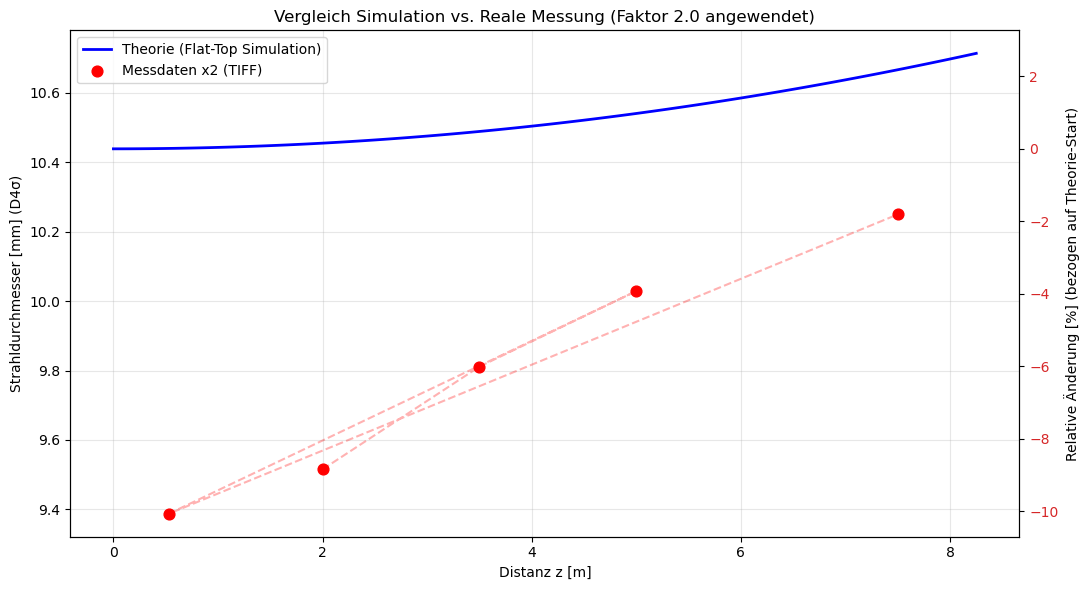

In [7]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==============================================================
# 1) PARAMETER & SETUP
# ==============================================================
lam            = 1064e-9      # Wellenlänge [m]
BEAM_DIAM_THEO = 11e-3        # Start-Durchmesser Theorie [m]
N              = 1024         
L              = 40e-3        # Simulationsfenster (40mm)
dx_sim         = L / N

# Kamera-Parameter
PIXEL_PITCH_UM = 5.5          # 5,5 µm
px_to_m        = PIXEL_PITCH_UM * 1e-6
FAKTOR_REAL    = 2.0          # Multiplikator für Realdaten

# ==============================================================
# 2) FUNKTIONEN
# ==============================================================

def get_d4sigma_m(I, spatial_dx):
    """Berechnet D4sigma Durchmesser in Metern."""
    h, w = I.shape
    x_coords = (np.arange(w) - w/2) * spatial_dx
    y_coords = (np.arange(h) - h/2) * spatial_dx
    X, Y = np.meshgrid(x_coords, y_coords)
    
    total = np.sum(I)
    if total <= 0: return 0.0
    
    P = I / total
    x_mean = np.sum(X * P)
    y_mean = np.sum(Y * P)
    
    cov_xx = np.sum(P * (X - x_mean)**2)
    cov_yy = np.sum(P * (Y - y_mean)**2)
    
    d4x = 4 * np.sqrt(max(cov_xx, 0))
    d4y = 4 * np.sqrt(max(cov_yy, 0))
    return np.sqrt(d4x * d4y)

def propagate_asm(U, dz):
    """Angular Spectrum Propagation."""
    k = 2 * np.pi / lam
    fx = np.fft.fftfreq(N, d=dx_sim)
    fy = np.fft.fftfreq(N, d=dx_sim)
    FX, FY = np.meshgrid(fx, fy)
    kz = np.sqrt((k+0j)**2 - (2*np.pi*FX)**2 - (2*np.pi*FY)**2)
    return np.fft.ifft2(np.fft.fft2(U) * np.exp(1j * kz * dz))

def extract_distance_m(filename):
    """Extrahiert 'cm' aus dem Dateinamen."""
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*cm", filename.lower())
    return float(m.group(1).replace(",", ".")) / 100.0 if m else None

# ==============================================================
# 3) REALDATEN EINLESEN (MIT VERDOPPLUNG)
# ==============================================================
def load_real_data():
    base_dir = Path(".")
    files = sorted(list(base_dir.glob("messung*.tiff")))
    z_list, d_list = [], []
    
    print(f"{'Datei':<25} | {'Abstand':<10} | {'D4sigma (x2)':<12}")
    print("-" * 55)
    
    for p in files:
        z_m = extract_distance_m(p.name)
        if z_m is None: continue
        
        img = np.array(Image.open(p), dtype=np.float64)
        img[img < 20] = 0 
        
        # Basis-Durchmesser berechnen
        d_m_raw = get_d4sigma_m(img, px_to_m)
        
        # Verdopplung anwenden
        d_m_final = d_m_raw * FAKTOR_REAL
        
        z_list.append(z_m)
        d_list.append(d_m_final * 1000) # m -> mm
        
        print(f"{p.name:<25} | {z_m:>7.2f} m | {d_m_final*1000:>8.2f} mm")
        
    return np.array(z_list), np.array(d_list)

# ==============================================================
# 4) AUSFÜHRUNG & PLOT
# ==============================================================

z_real, d_real = load_real_data()

# Theorie-Simulation
z_max_plot = max(z_real) * 1.1 if len(z_real) > 0 else 2.5
z_theo = np.linspace(0, z_max_plot, 100)
w0 = BEAM_DIAM_THEO / 2
X_s, Y_s = np.meshgrid((np.arange(N)-N/2)*dx_sim, (np.arange(N)-N/2)*dx_sim)
U_start = np.exp(-(np.sqrt(X_s**2 + Y_s**2)/w0)**20).astype(complex)

d_theo = []
for zi in z_theo:
    U_z = propagate_asm(U_start, zi)
    dt = get_d4sigma_m(np.abs(U_z)**2, dx_sim)
    d_theo.append(dt * 1000)

# Plotten
fig, ax1 = plt.subplots(figsize=(11, 6))

# Theorie
ax1.plot(z_theo, d_theo, 'b-', label='Theorie (Flat-Top Simulation)', lw=2)

# Real (Verdoppelt)
if len(z_real) > 0:
    ax1.scatter(z_real, d_real, color='red', s=60, label='Messdaten x2 (TIFF)', zorder=5)
    ax1.plot(z_real, d_real, 'r--', alpha=0.3)

ax1.set_xlabel("Distanz z [m]")
ax1.set_ylabel("Strahldurchmesser [mm] (D4σ)")
ax1.set_title(f"Vergleich Simulation vs. Reale Messung (Faktor {FAKTOR_REAL} angewendet)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Zweite Y-Achse für % Zunahme
ax2 = ax1.twinx()
y1, y2 = ax1.get_ylim()
ref_size = d_theo[0]
ax2.set_ylim(((y1 - ref_size)/ref_size)*100, ((y2 - ref_size)/ref_size)*100)
ax2.set_ylabel("Relative Änderung [%] (bezogen auf Theorie-Start)")
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.tight_layout()
plt.show()